# 04 — Modeling: Engine Rekomendasi Hybrid

```
score = 0.30*similarity_konten + 0.35*kedekatan_geo
      + 0.20*popularitas + 0.15*buka_di_hari_terpilih
```

Cold-start friendly — tidak butuh riwayat user.

In [1]:
import sys
import os
sys.path.insert(0, "../..")
sys.path.insert(0, "../../06_api")

import pandas as pd
import matplotlib.pyplot as plt
from recommend import Recommender, WEIGHTS, DAYS

## Bobot komponen skor

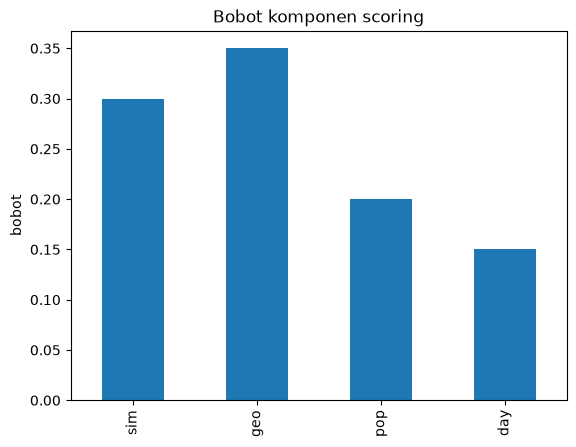

In [2]:
pd.Series(WEIGHTS).plot(kind="bar", title="Bobot komponen scoring")
plt.ylabel("bobot")
plt.show()

## Inisialisasi engine

In [3]:
import os
csv_path = os.path.join(os.path.dirname(os.path.abspath(".")), 
                        "data", "processed", "merged_venues_enriched.csv")
# Dari docs/notebooks/ -> naik 2 level ke root
csv_path = "../../data/processed/merged_venues_enriched.csv"

rec = Recommender(csv_path=csv_path)
print(f"Total venue ter-load: {len(rec.df)}")
print(f"Kolom: {list(rec.df.columns[:10])}...")

Total venue ter-load: 393
Kolom: ['venue_id', 'name', 'venue_category', 'latitude', 'longitude', 'address', 'checkin_count', 'last_checkin', 'osm_url', 'References']...


## Demo: turis di Monas, suka museum, kunjungan Sabtu

In [4]:
res = rec.recommend(lat=-6.1754, lon=106.8272,
                     category="Museum", day="Sabtu", top_n=10)
res

,venue_id,name,venue_category,distance_km,jam_buka,google_rating,google_rating_count,References,score
342,google_00104,Galeri Demono,Museum,3.07,07:00 - 13:00,5.0,272.0,NaN,0.9571
324,google_00086,Museum MH. Thamrin,Museum,2.91,09:00 - 16:00,4.6,946.0,NaN,0.9433
323,google_00085,Lembaga Alkitab Indonesia,Museum,3.43,08:00 - 15:00,4.7,118.0,NaN,0.9400
321,google_00083,Magic Art 3D Museum Jakarta,Museum,4.70,10:00 - 19:00,4.7,2346.0,NaN,0.9222
328,google_00090,Bentara Budaya Jakarta,Museum,5.23,09:00 - 20:00,4.6,2595.0,NaN,0.9108
339,google_00101,Taman Benyamin Sueb (Gedung Eks Kodim),Museum,6.65,08:00 - 16:00,4.7,305.0,NaN,0.8949
329,google_00091,Warung buah segar.,Museum,5.23,07:00 - 17:00,4.2,138.0,NaN,0.8947
352,google_00114,Loonami House K-Pop Studio,Museum,6.85,10:00 - 21:00,4.4,494.0,NaN,0.8800
211,58223,Museum Alkitab Indonesia,Museum,9.02,09:00 - 15:00,4.9,33.0,https://www.google.com/maps/search/?api=1&quer...,0.8697
347,google_00109,Istana Boneka Kelapa Gading (Isbon),Museum,9.42,09:00 - 22:00,4.9,537.0,NaN,0.8642


## Demo: cold-start, tanpa preferensi kategori (netral)

In [5]:
res_netral = rec.recommend(lat=-6.1754, lon=106.8272, top_n=10)
res_netral

,venue_id,name,venue_category,distance_km,jam_buka,google_rating,google_rating_count,References,score
170,37787,Ruangan Proklamasi (Monas),History Museum,0.23,,4.7,7389.0,NaN,0.6847
0,6,Monumen Nasional (MONAS),Monument / Landmark,0.00,,4.6,122100.0,https://id.wikipedia.org/wiki/Monumen_Nasional,0.6840
1,328,Museum Nasional Indonesia,Museum,0.49,,4.7,20316.0,https://www.wikidata.org/wiki/Q137947145,0.6812
319,google_00081,National Museum of Indonesia,Museum,0.61,,4.7,20317.0,NaN,0.6795
11,832,Galeri Nasional Indonesia,Museum,0.66,,4.7,10813.0,NaN,0.6788
184,44851,Museum Katedral - Jakarta,History Museum,0.98,,4.8,210.0,NaN,0.6782
330,google_00092,Gedung Pancasila,Museum,0.71,,4.7,404.0,NaN,0.6780
132,25297,Vihara Dharma Jaya (Sin Tek Bio),Temple,1.63,,5.0,4.0,NaN,0.6771
278,google_00040,Istiqlal Mosque Fountain,Theme Park,0.54,,4.6,83.0,NaN,0.6765
206,55752,Pura Aditya Jaya,Temple,1.30,,4.8,3167.0,NaN,0.6738


## Pengaruh jarak terhadap skor (sanity check komponen geo)

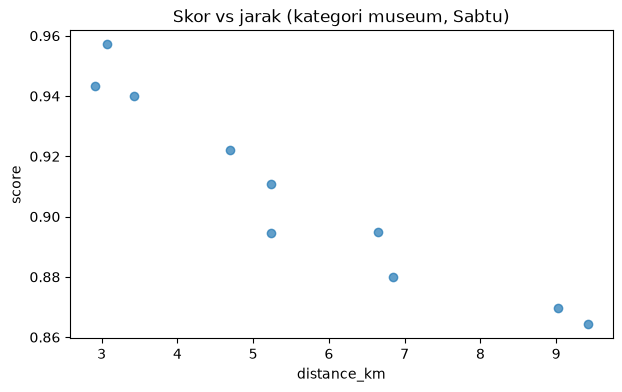

In [6]:
plt.figure(figsize=(7, 4))
plt.scatter(res["distance_km"], res["score"], alpha=0.7)
plt.xlabel("distance_km")
plt.ylabel("score")
plt.title("Skor vs jarak (kategori museum, Sabtu)")
plt.show()

## Eksperimen: ubah filter `only_open` (venue tutup di hari terpilih di-exclude)

In [7]:
res_open_only = rec.recommend(lat=-6.1754, lon=106.8272,
                               category="Museum", day="Sabtu",
                               top_n=10, only_open=True)
print(f"Tanpa filter only_open: {len(res)} hasil")
print(f"Dengan filter only_open: {len(res_open_only)} hasil")

Tanpa filter only_open: 10 hasil
Dengan filter only_open: 10 hasil
